# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

from environment.environment import Environment
from experiment import Experiment
from campaigns.uniform_bids_stochastic_campaign import UniformBidsStochasticCampaign
from bidders.UCB_based.combinatorial_ucb_like_bidder_simplified import CombinatorialUCBLikeBidder as CombinatorialUCBLikeBidderSimplified
from bidders.UCB_based.combinatorial_ucb_like_bidder_true import CombinatorialUCBLikeBidder as CombinatorialUCBLikeBidderTrue

import plots

## Requirement 2: Multiple campaigns and stochastic environment

### Environment

Build a stochastic environment:
- A joint distribution over the highest competing bids for each campaign

In [2]:
N_TRIALS = 10  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=5, campaign_type=UniformBidsStochasticCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=137)  # 137 generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 10000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.04  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

np.random.seed(123)
MY_VALUATIONS = np.random.uniform(low=0.3, high=0.9, size=environment.N_CAMPAIGNS)
print("Per-campaign valuations:", MY_VALUATIONS)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 5
Campaigns:
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1. 1.]
    Number of advertisers: 5
    Number of competitors: 4
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform dis

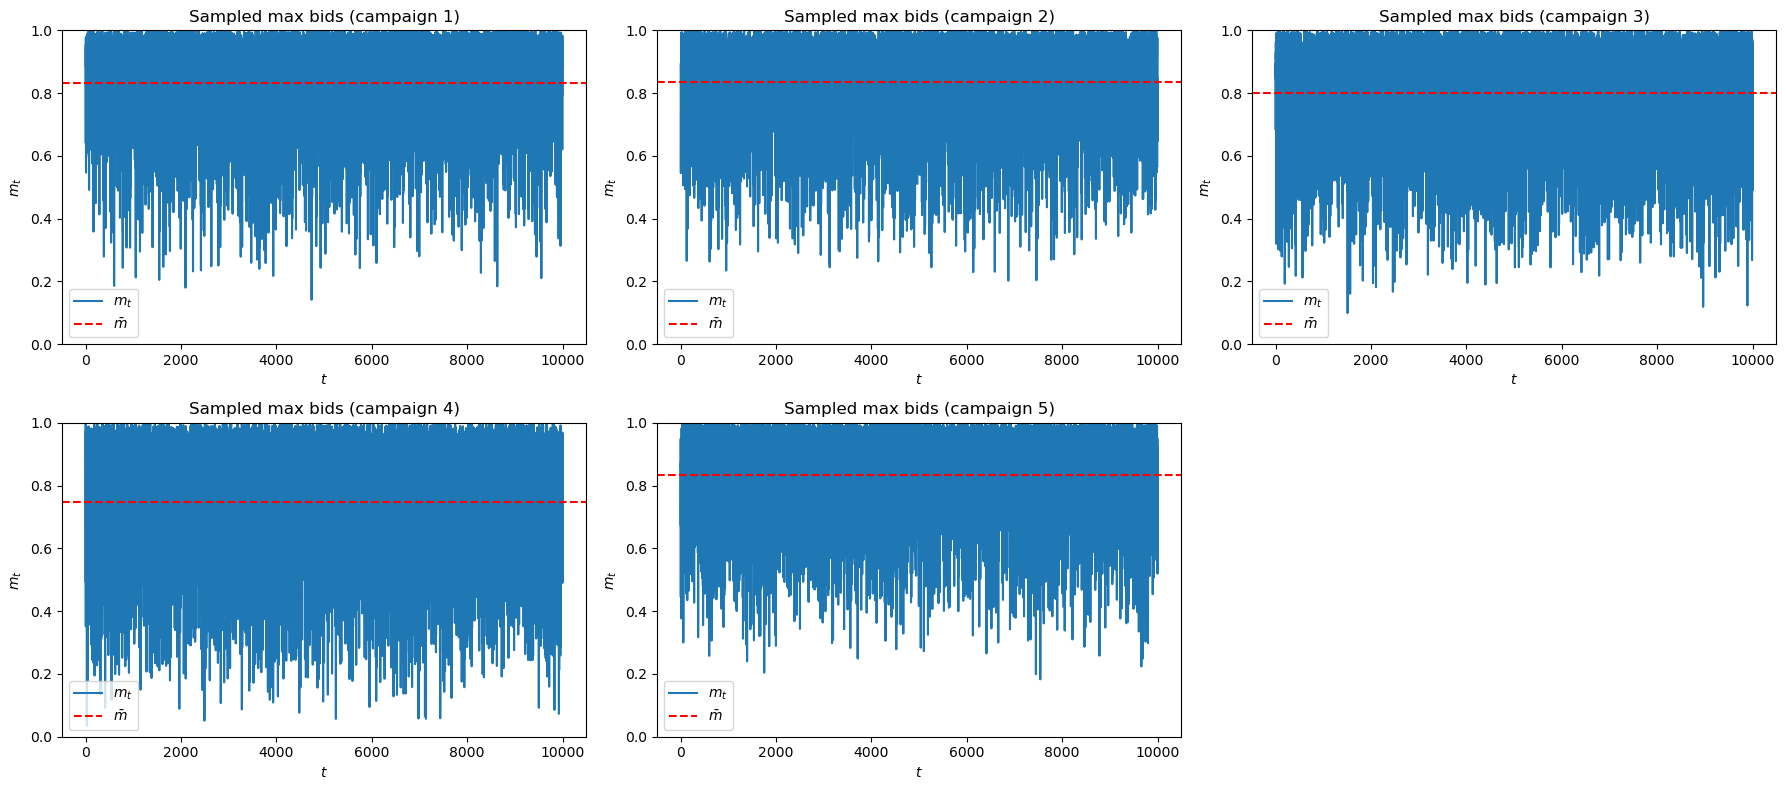

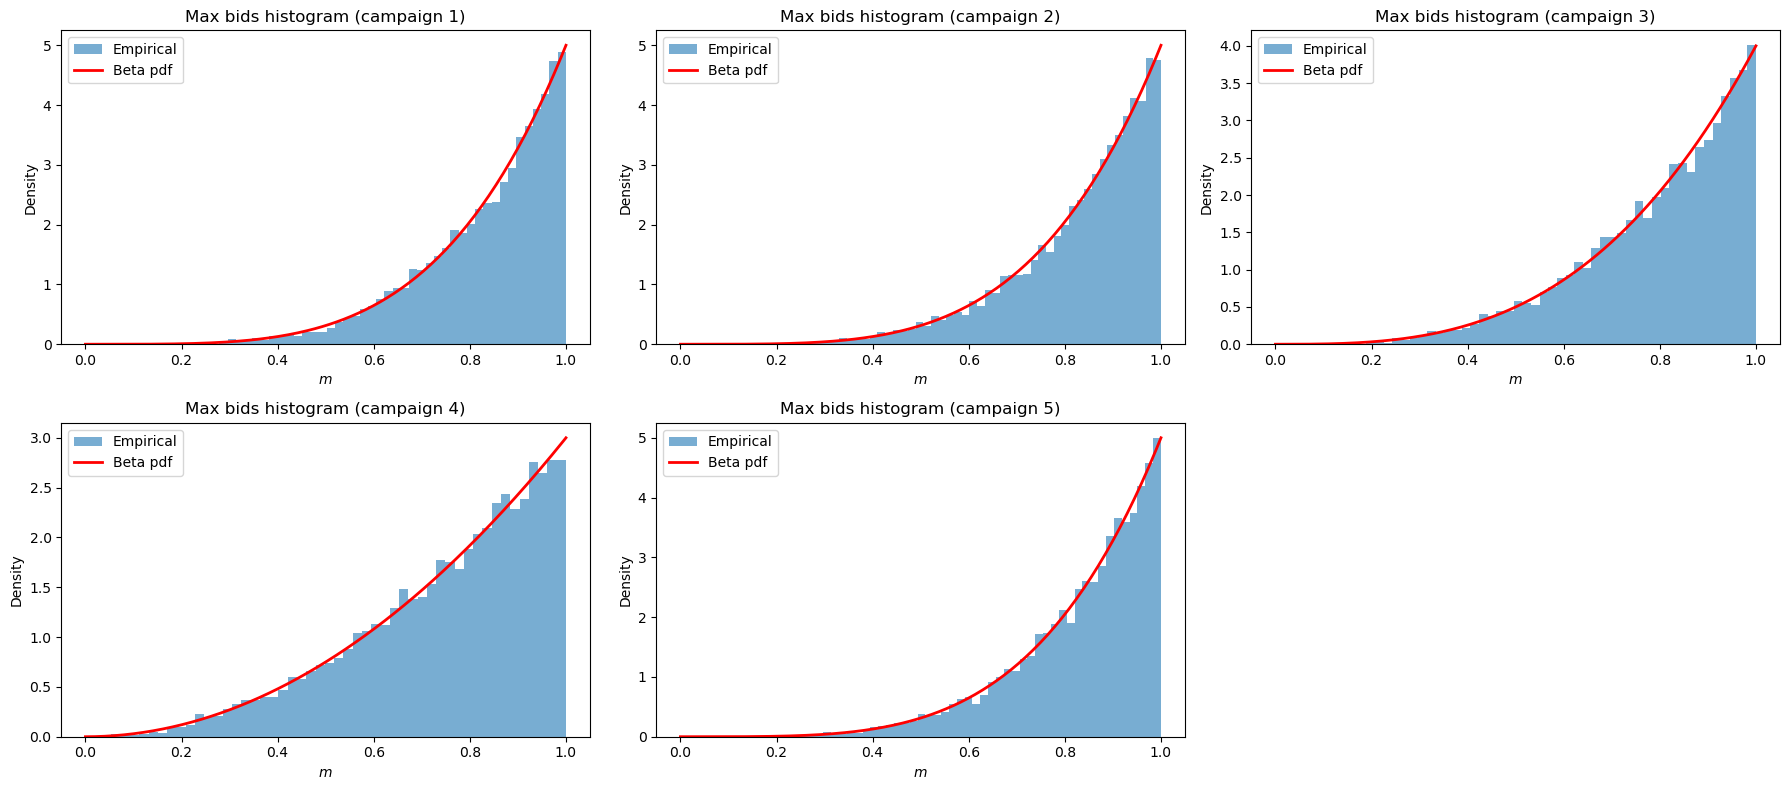

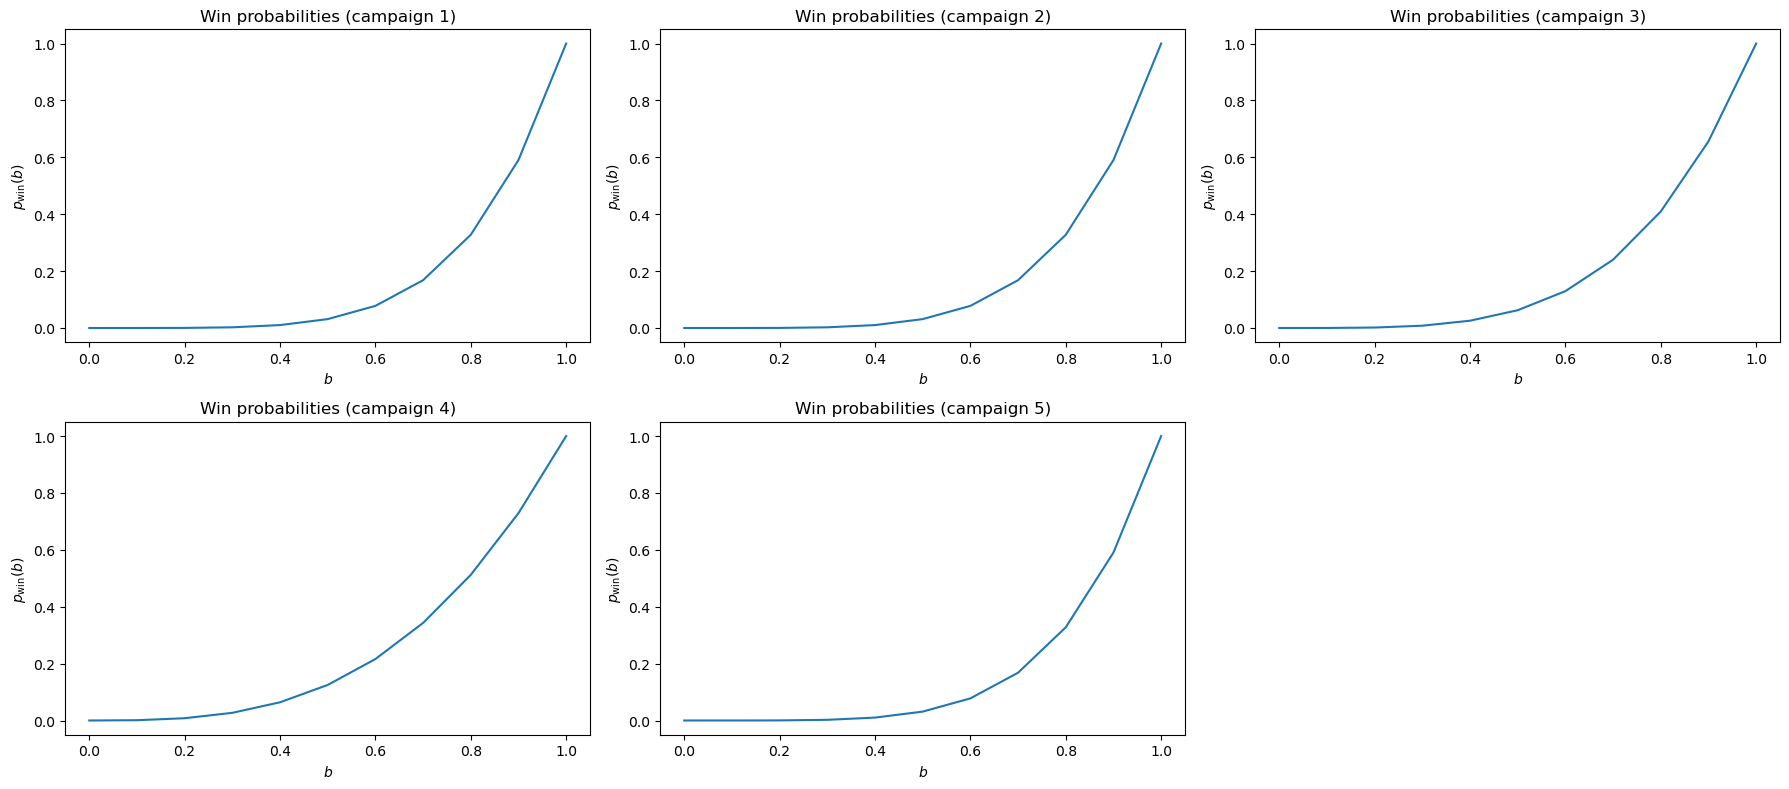

In [3]:
for i, campaign in enumerate(environment.campaigns):
    campaign.generate_random_competing_bids(n_users=N_USERS, seed=47+i)  # generate random competing bids for each advertiser in the campaign

plots.plot_req2_sampled_max_bids_in_time(environment)
plots.plot_req2_max_bids_histogram(environment)
plots.plot_win_probabilities(environment, BIDS_SPACE, 'req2_win_probabilities.png')

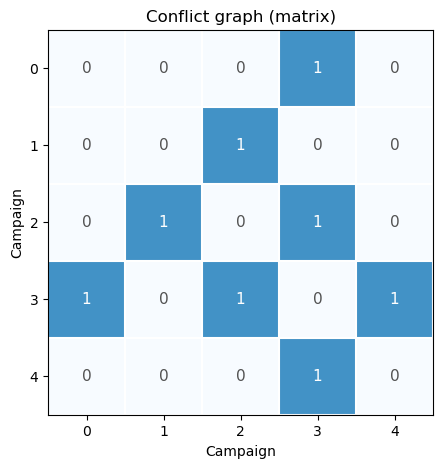

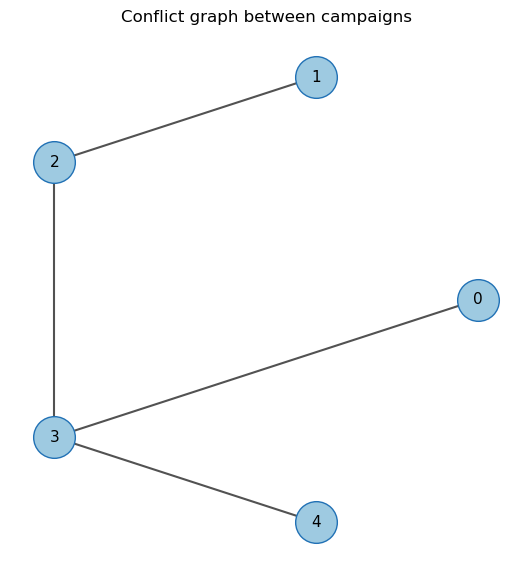

In [ ]:
plots.plot_conflict_graph_between_campaigns_matrix_version(environment, 'req2_conflict_matrix.png')
plots.plot_conflict_graph_between_campaigns(environment, 'req2_conflict_graph.png')

### Design algorithms for multiple campaigns and stochastic environment

- Build a bidding strategy using Combinatorial-UCB with budget constraint.

Hint: Extend the “UCB-like” approach that we saw for a single campaign to multiple
campaigns.

In [5]:
auxiliary_bidder = CombinatorialUCBLikeBidderSimplified(B=STARTING_BUDGET, T=N_USERS, valuations=MY_VALUATIONS.tolist(), environment=environment)

true_clairvoyant_campaign_gammas, true_clairvoyant_superarm_gammas, true_clairvoyant_expected_utilities, true_clairvoyant_expected_payments = environment.compute_true_combinatorial_clairvoyant(auxiliary_bidder, campaign_indices=None)
simplified_clairvoyant_campaign_gammas, simplified_clairvoyant_superarm_gammas, simplified_clarvoyant_expected_utiities, simplified_clairvoyant_expected_payments = environment.compute_simplified_combinatorial_clairvoyant(auxiliary_bidder, campaign_indices=None)

print("True clairvoyant expected utility: ", true_clairvoyant_expected_utilities[0])
print("Simplified clairvoyant expected utility: ", simplified_clarvoyant_expected_utiities[0])
print("True clairvoyant expected payment: ", true_clairvoyant_expected_payments[0])
print("Simplified clairvoyant expected payment: ", simplified_clairvoyant_expected_payments[0])

print("Increase in true clairvoyant utility: ", true_clairvoyant_expected_utilities[0] - simplified_clarvoyant_expected_utiities[0])
print("Increase in true clairvoyant payment: ", true_clairvoyant_expected_payments[0] - simplified_clairvoyant_expected_payments[0])

True clairvoyant expected utility:  0.016285210741043048
Simplified clairvoyant expected utility:  0.015386339054128496
True clairvoyant expected payment:  0.039999999999999994
Simplified clairvoyant expected payment:  0.04
Increase in true clairvoyant utility:  0.000898871686914552
Increase in true clairvoyant payment:  -6.938893903907228e-18


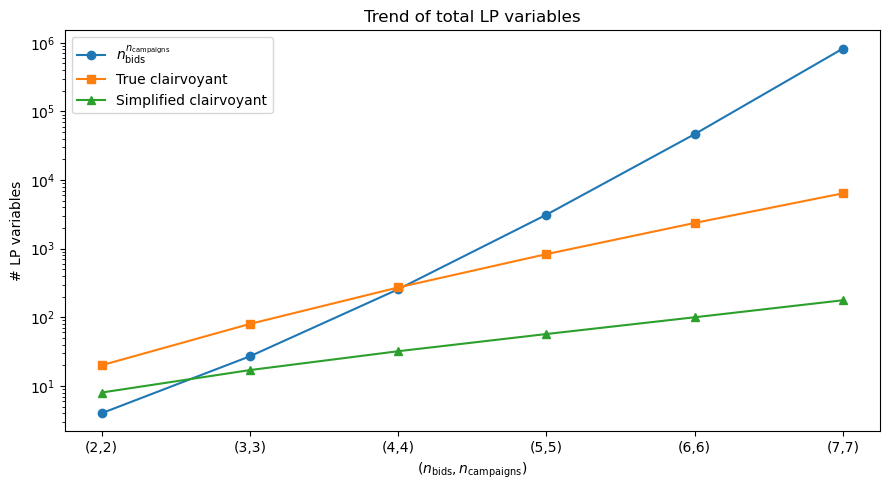

In [6]:
plots.plot_req2_trend_total_LP_variables_growing_with_n_campaigns_and_n_bids()

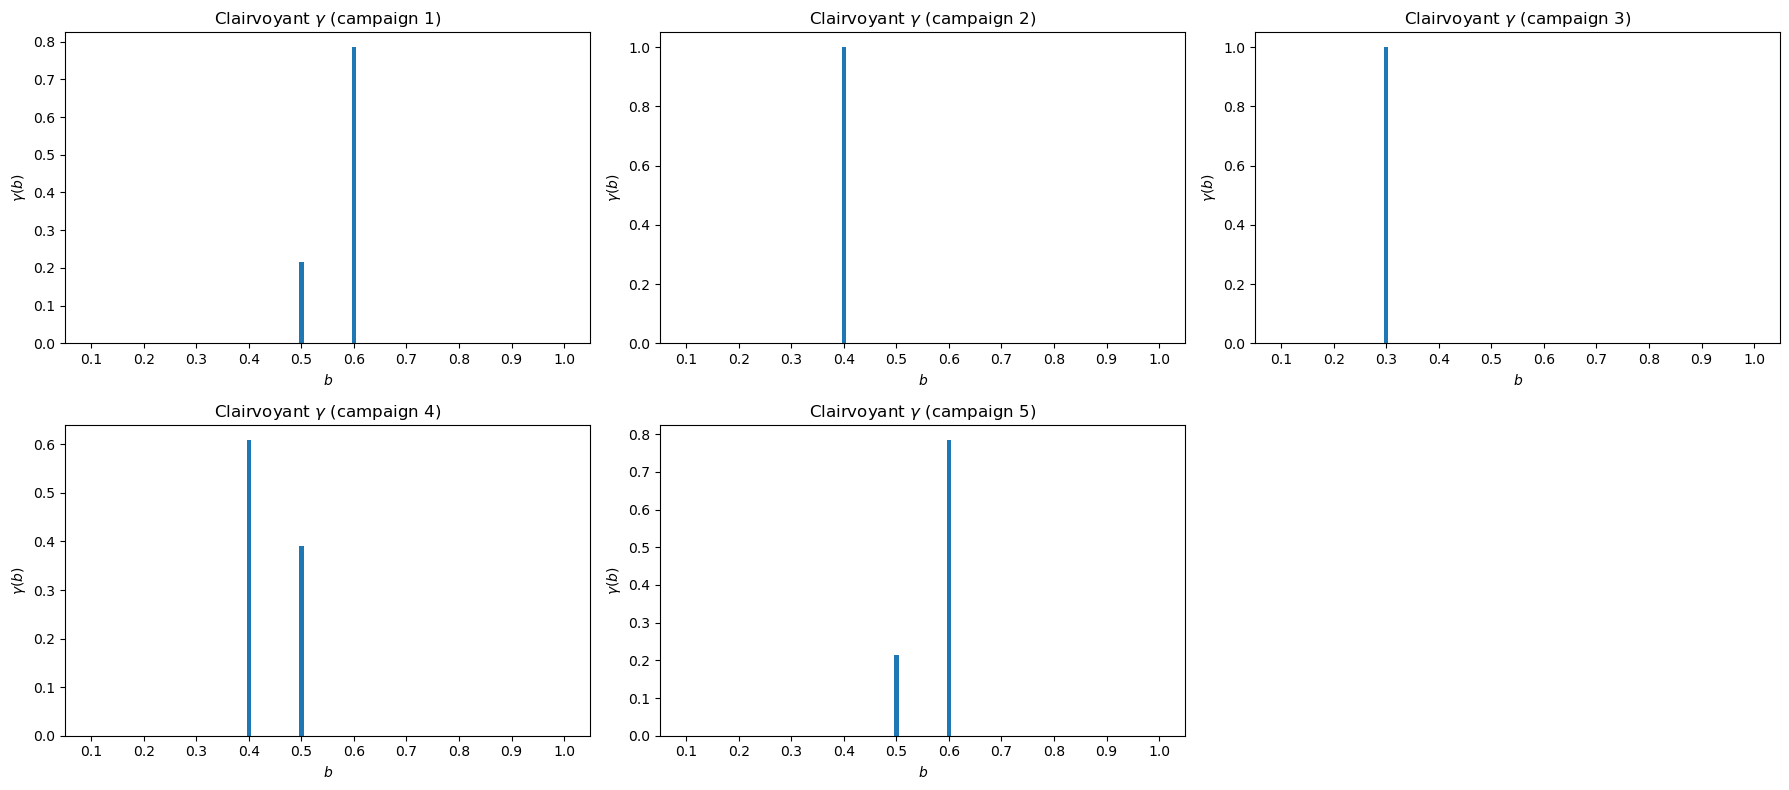

In [7]:
plots.plot_req2_clairvoyant_distribution_over_bids(bidder=auxiliary_bidder, gammas=simplified_clairvoyant_campaign_gammas)

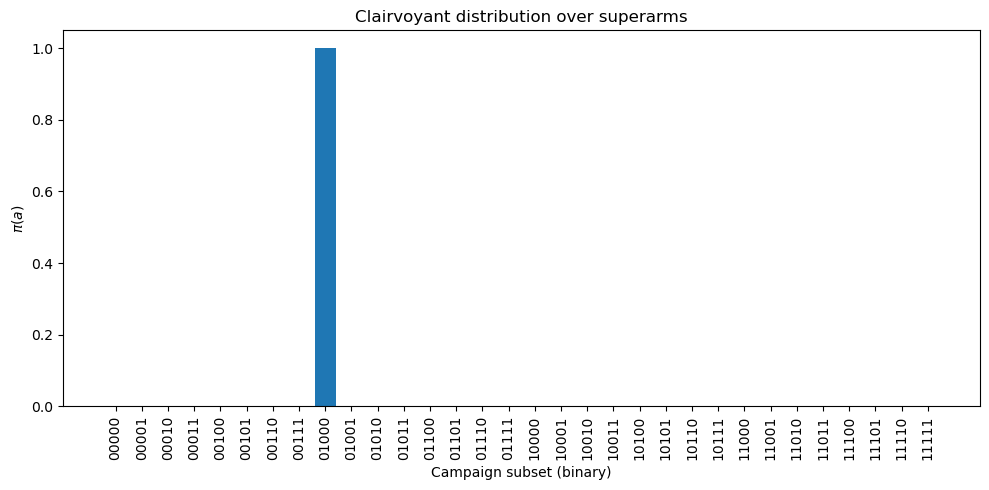

In [8]:
plots.plot_req2_clairvoyant_distribution_over_campaigns_subsets(superarm_gammas=simplified_clairvoyant_superarm_gammas, save_name="req2_simpified_clairvoyant_superarm_distribution.png")

In [9]:
# NOTE: useless because we have too many gammas for eachc campaign (one for each campaign subset) -> one could maybe plot how the distribution changes for campaign 0 across the various subsets
#plots.plot_req2_clairvoyant_distribution_over_bids(bidder=auxiliary_bidder, gammas=true_clairvoyant_campaign_gammas)

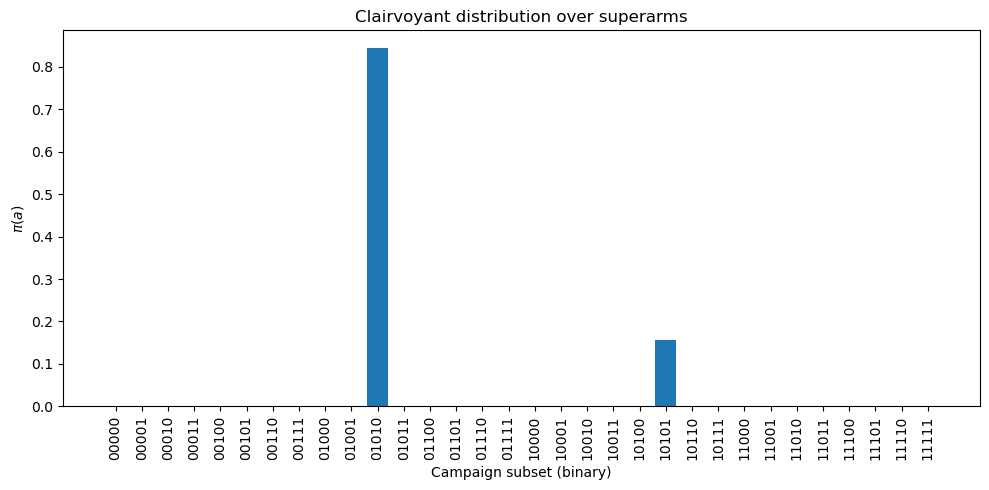

In [10]:
plots.plot_req2_clairvoyant_distribution_over_campaigns_subsets(superarm_gammas=true_clairvoyant_superarm_gammas, save_name="req2_true_clairvoyant_superarm_distribution.png")

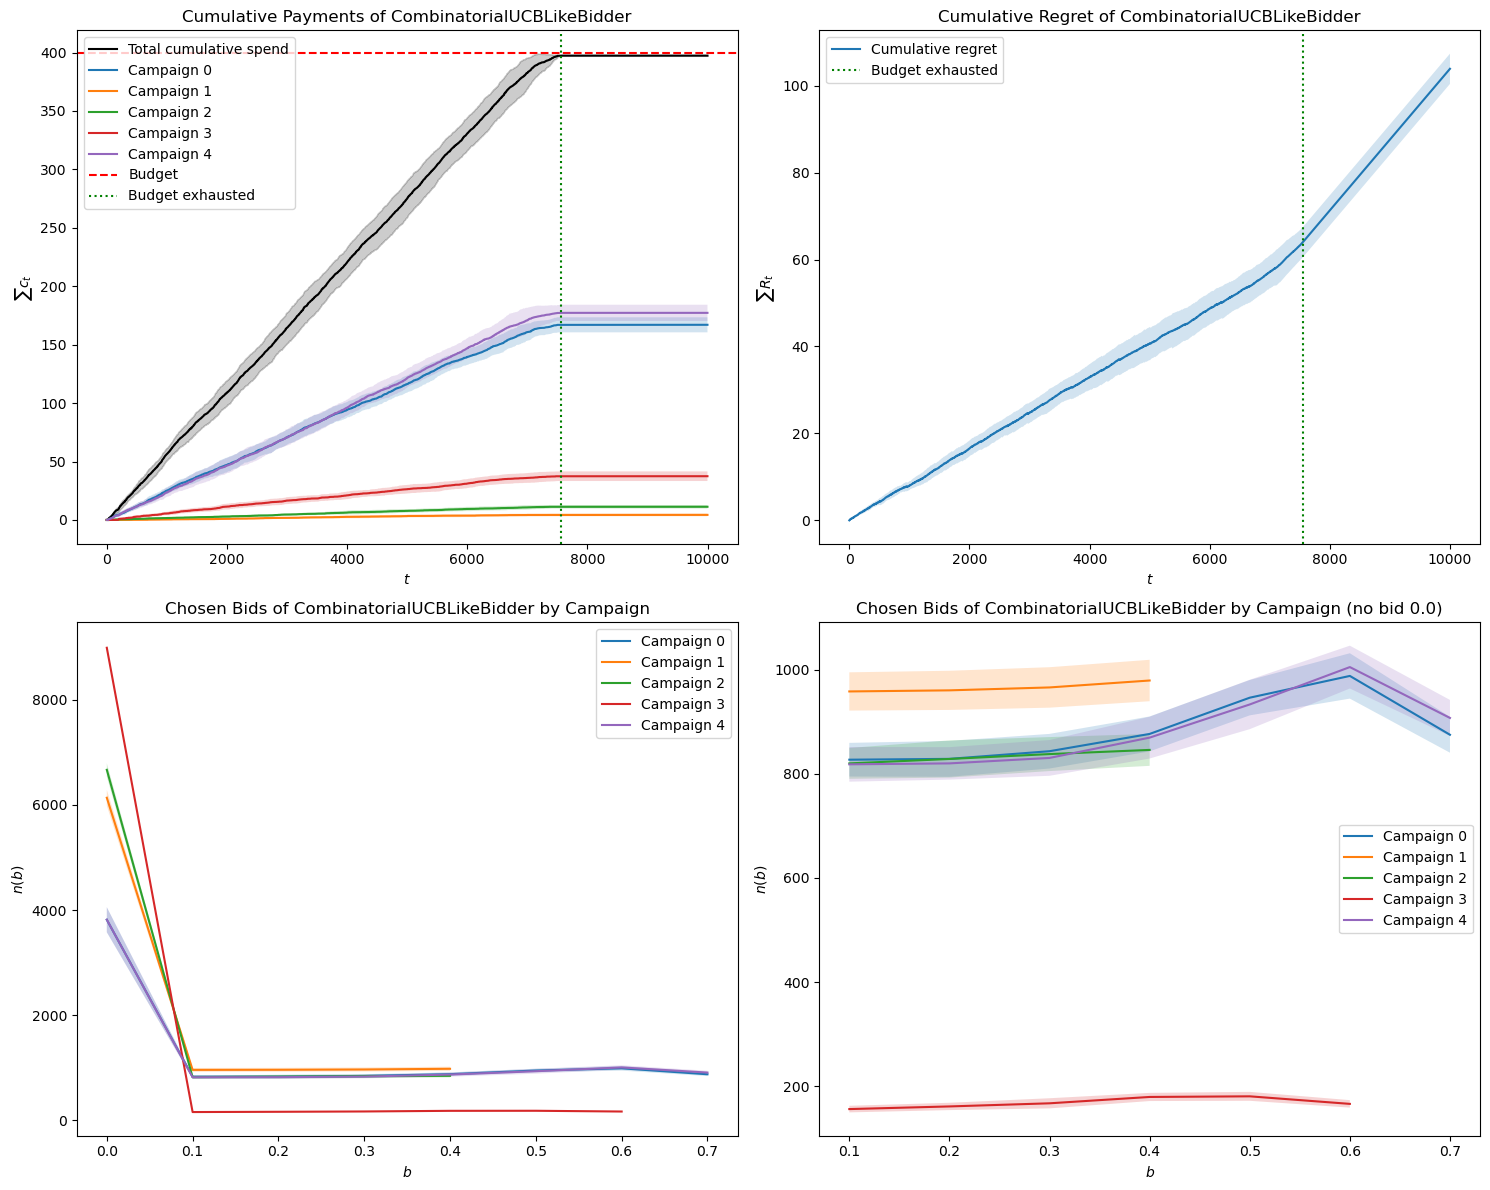

In [11]:
budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true = Experiment(environment=environment,
                                                          bidder_class=CombinatorialUCBLikeBidderSimplified, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment
                                                            })

budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true', seed=10)

plots.plot_experiment_result(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true, "req2_simplified_true_experiment_results.png")

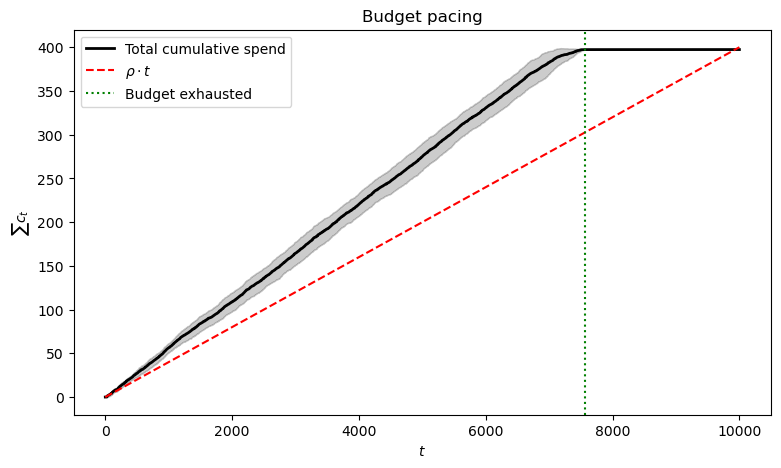

In [12]:
plots.plot_req2_budget_pacing(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true)

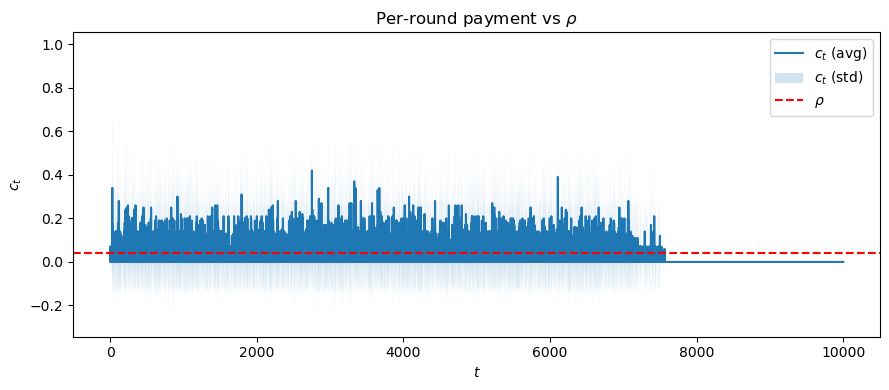

In [13]:
plots.plot_req2_per_round_payment_vs_rho(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true)

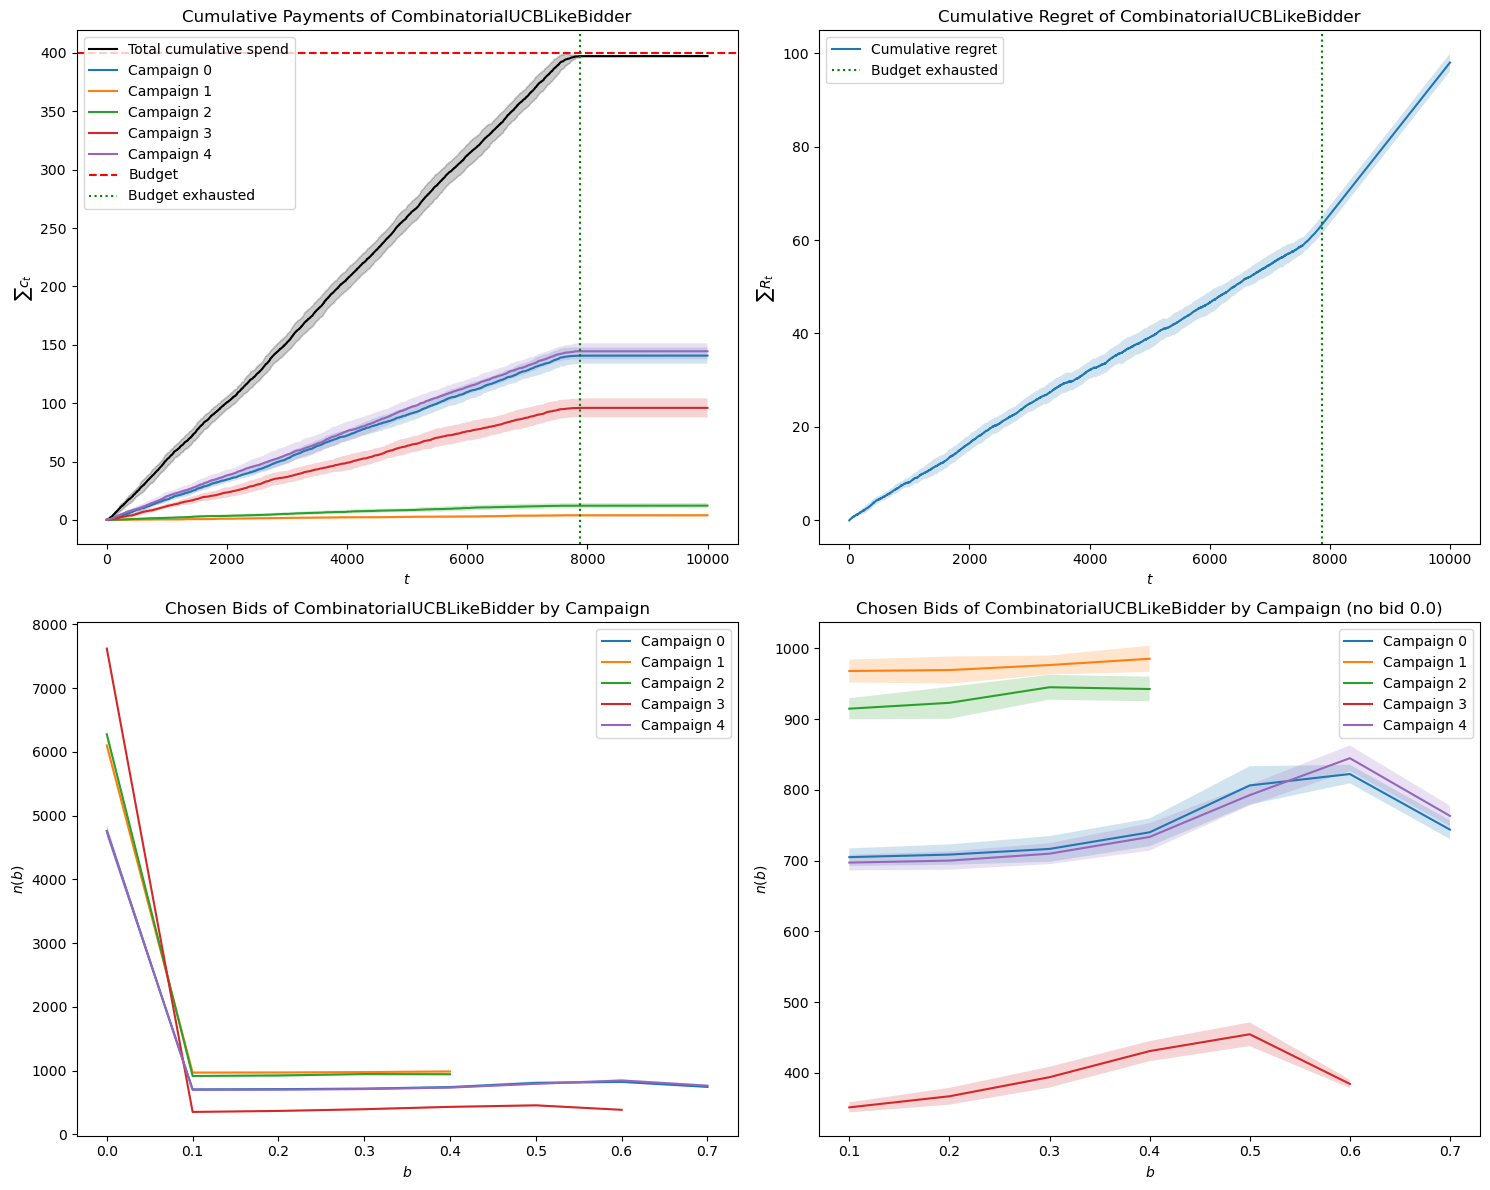

In [ ]:
budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true = Experiment(environment=environment,
                                                          bidder_class=CombinatorialUCBLikeBidderTrue, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment
                                                            })

budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true')

plots.plot_experiment_result(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true, "req2_true_true_experiment_results.png")

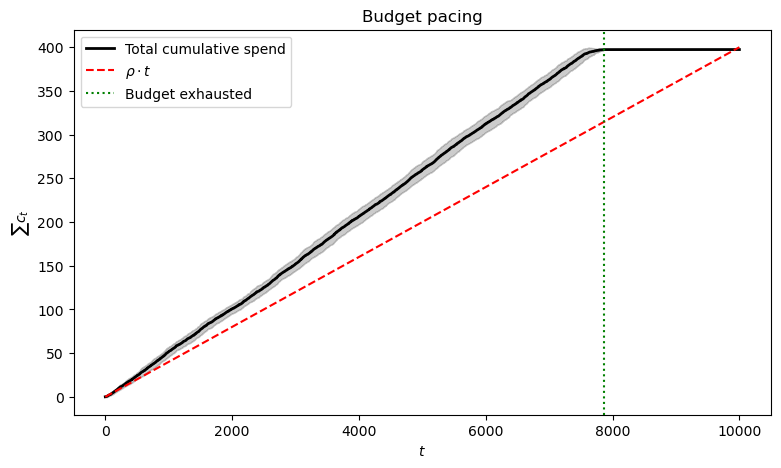

In [15]:
plots.plot_req2_budget_pacing(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true)

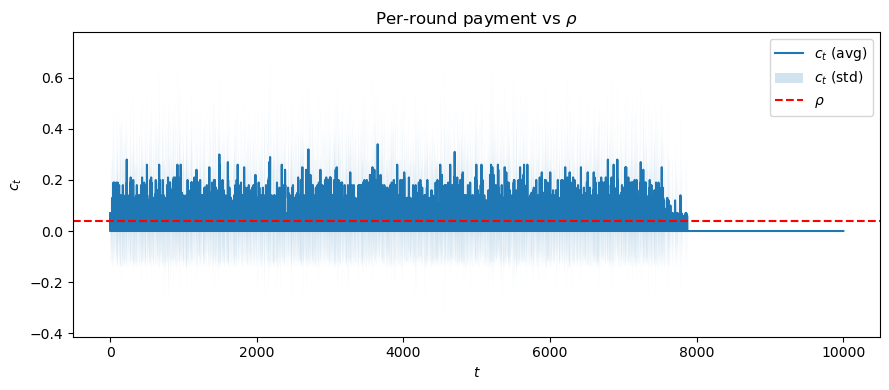

In [16]:
plots.plot_req2_per_round_payment_vs_rho(budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true)

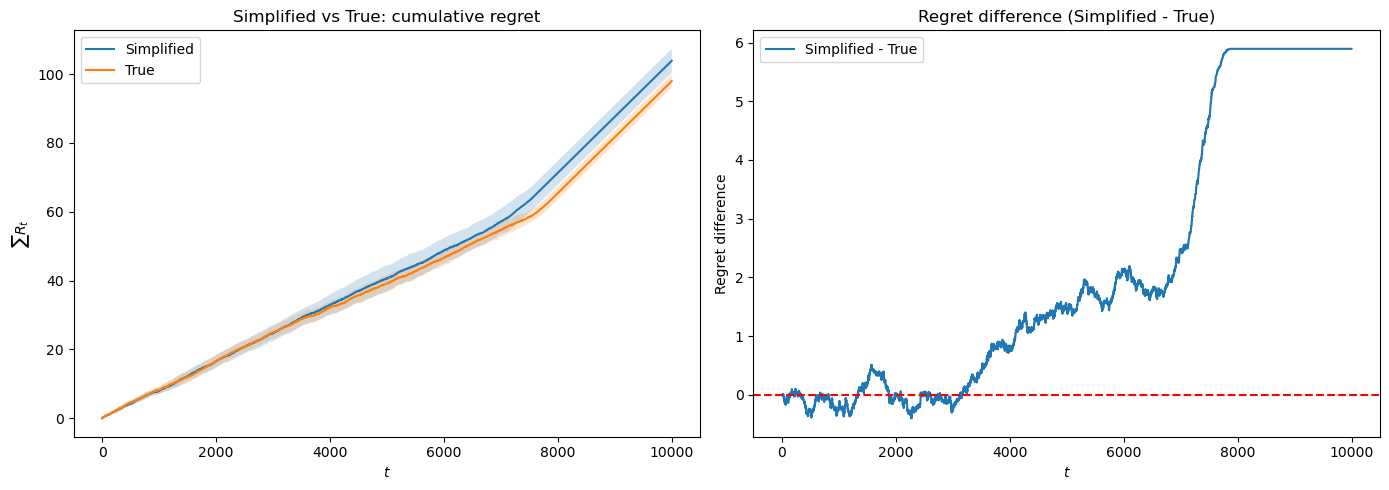

In [17]:
plots.plot_req2_combinatorial_simplified_vs_combinatorial_true_regrets_comparison(
    budget_constrained_single_campaign_combinatorial_UCB_like_experiment_simplified_true,
    budget_constrained_single_campaign_combinatorial_UCB_like_experiment_true_true
)